In [90]:
import os
from langgraph.graph import StateGraph, START, END, add_messages
from typing import TypedDict, Annotated
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from operator import add
from langgraph.checkpoint.memory import MemorySaver

In [91]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] # instead of str we took baseModel why ;; bz what ever messages we have studied (humanMessages, systemMessags are inheritent with BaseMessage)
    # so it means it can have any kind messages ;; reducer fn add instead we use a specialised add messageas fn "add_messages" and it is build fn of langgraph;; bz it reduces is very optimise with BaseMessages
    

In [92]:
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="chat-completions",
    huggingfacehub_api_token= os.getenv("HUGGINGFACEHUB_API_TOKEN"),
    max_new_tokens=25
    
)

model= ChatHuggingFace(llm= llm)


def chat_with(state:ChatState):

    state['messages'].append(SystemMessage(content="You are a Question Answering Chat bot, and if you don't know anythings just tell you don't know instead of telling irrelevent things"))


    prompt= ChatPromptTemplate.from_messages(state['messages'])

    parser= StrOutputParser()

    global model

    chain= prompt|model| parser

    result= chain.invoke({})

    return {"messages":[AIMessage(content=result)]}
    

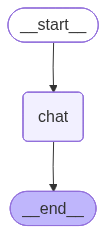

In [93]:
checkpointer= MemorySaver()

graph= StateGraph(ChatState)

graph.add_node("chat", chat_with)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

workflow= graph.compile(checkpointer=checkpointer)

workflow

In [94]:
initial_state={'messages':[HumanMessage(content="who is the prime minister of india?")]}

# workflow.invoke(initial_state)

In [95]:
thread_id="1"
flag= True
while flag:
    hum_res= input("User:")
    print(f"User: {hum_res}") # so user can also see it's message
    if hum_res.strip().lower() in ["stop", "quit", "bye"]:
        flag= False
    else:
        initial_state= {"messages":[HumanMessage(content=hum_res)]}
        config= {"configurable":{"thread_id":thread_id}}
        res= workflow.invoke(initial_state, config=config)["messages"][-1].content
        print(f"Ai:{res}")
    

User: my name is aditya
Ai: Hello Aditya! Nice to meet you. How can I assist you today?
User: what is my name
Ai: Your name is Aditya, as you mentioned at the beginning of our conversation. Is there something specific you would like help
User: stop


## What is the problem here, the memory -> here we are invoking it again-and-again , we are not maintaining any kind of memory , for that we should be a such kind of workflow in which a looping will be happened then it can get a state which basically contain the previous conversation

* i meant that when ever you call invoke , it just means you doing things from scratch again or you state will initalize from empty

In [97]:
## now what happening , so our conversation is not get erased at the end , we are stroing those whole conversation in our ram memory and every invoke 
## our model is getting whole coverstion ;; or in our state the whole conversation are being stored

In [101]:
workflow.get_state(config=config) # and by config we have to menstion who was really chating

StateSnapshot(values={'messages': [HumanMessage(content='my name is aditya', additional_kwargs={}, response_metadata={}, id='9e51053b-612d-4a09-838e-f1e98fb52b45'), SystemMessage(content="You are a Question Answering Chat bot, and if you don't know anythings just tell you don't know instead of telling irrelevent things", additional_kwargs={}, response_metadata={}, id='0c77a194-97f7-4e0d-be88-b3e8f8d1bcda'), AIMessage(content=' Hello Aditya! Nice to meet you. How can I assist you today?', additional_kwargs={}, response_metadata={}, id='5c798ec6-baca-4f41-b9b1-e480b3b577b2', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='8572b526-6efc-4a37-87ac-456090d790be'), SystemMessage(content="You are a Question Answering Chat bot, and if you don't know anythings just tell you don't know instead of telling irrelevent things", additional_kwargs={}, response_metadata={}, id='8fa89123-bf5c-4052-ab84-f3f83379ecb6'), AIMessa